# EDA — QQQ 5-min Features with GEX Overlay

Quick sanity pass and feature exploration before training. Looking for: target distribution shape, feature–target signal, multicollinearity, time-series artifacts, and any leakage I missed in `build_dataset.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", rc={"figure.dpi": 100})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

df = pd.read_parquet("../data/qqq_5m_features.parquet")

TARGET = "target_15m_return"
FEATURES_BASELINE = [
    "log_return_5m", "log_return_15m", "log_return_30m", "log_return_60m",
    "realized_vol_60m", "atr_14",
    "volume_zscore_20", "log_dollar_volume",
    "close_position", "close_vs_sma20", "rsi_14",
    "minutes_since_open", "hour_sin", "hour_cos",
]
FEATURES_GEX = [
    "dist_call_wall_atr", "dist_put_wall_atr", "dist_zero_gamma_atr",
    "above_zero_gamma",
    "net_gex", "abs_gex_total", "gex_concentration", "gex_age_minutes",
]
ALL_FEATURES = FEATURES_BASELINE + FEATURES_GEX

print(f"Shape: {df.shape}")
print(f"Date range: {df.date.min()} → {df.date.max()}")
print(f"Trading days covered: {df.date.dt.date.nunique()}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (1095, 26)
Date range: 2026-04-24 14:05:00+00:00 → 2026-05-15 19:40:00+00:00
Trading days covered: 16


,date,computed_at,target_time,target_15m_return,log_return_5m,log_return_15m,log_return_30m,log_return_60m,realized_vol_60m,atr_14,volume_zscore_20,log_dollar_volume,close_position,close_vs_sma20,rsi_14,minutes_since_open,hour_sin,hour_cos,dist_call_wall_atr,dist_put_wall_atr,dist_zero_gamma_atr,above_zero_gamma,net_gex,abs_gex_total,gex_concentration,gex_age_minutes
0,2026-04-24 14:05:00+00:00,2026-04-24 14:00:01.369775+00:00,2026-04-24 14:20:00+00:00,0.0002,0.0016,0.0021,-0.0007,0.0800,0.0209,4.7443,-0.1092,19.7949,0.8077,0.0365,92.8011,35.0000,-0.5188,-0.8549,-0.4342,0.8305,-0.3309,-1.0000,3161288.5600,7585707.5600,0.2549,4.9772
1,2026-04-24 14:10:00+00:00,2026-04-24 14:00:01.369775+00:00,2026-04-24 14:25:00+00:00,-0.0014,0.0002,0.0016,0.0007,0.0802,0.0209,4.7014,0.0157,19.9612,0.3689,0.0327,95.1346,40.0000,-0.5373,-0.8434,-0.4084,0.8678,-0.3042,-1.0000,3161288.5600,7585707.5600,0.2549,9.9772
2,2026-04-24 14:15:00+00:00,2026-04-24 14:00:01.369775+00:00,2026-04-24 14:30:00+00:00,-0.0018,0.0003,0.0021,0.0002,0.0076,0.0019,4.7264,-0.2148,19.6600,0.5204,0.0290,95.4562,45.0000,-0.5556,-0.8315,-0.3660,0.9034,-0.2624,-1.0000,3161288.5600,7585707.5600,0.2549,14.9772
3,2026-04-24 14:20:00+00:00,2026-04-24 14:15:01.362446+00:00,2026-04-24 14:35:00+00:00,-0.0001,-0.0003,0.0002,0.0023,0.0068,0.0019,4.7536,-0.4005,19.3149,0.4375,0.0247,95.0782,50.0000,-0.5736,-0.8192,-0.1998,1.9038,19.1730,1.0000,133075761.9800,229270325.3200,0.1933,4.9773
4,2026-04-24 14:25:00+00:00,2026-04-24 14:15:01.362446+00:00,2026-04-24 14:40:00+00:00,0.0020,-0.0014,-0.0014,0.0002,0.0046,0.0020,1.5407,-0.1420,19.7892,0.1947,0.0194,67.1135,55.0000,-0.5913,-0.8064,-1.2072,5.2833,58.5637,1.0000,133075761.9800,229270325.3200,0.1933,9.9773


## 1. Target distribution

15-minute log return on QQQ. We want: roughly symmetric, mean near zero, fat tails.

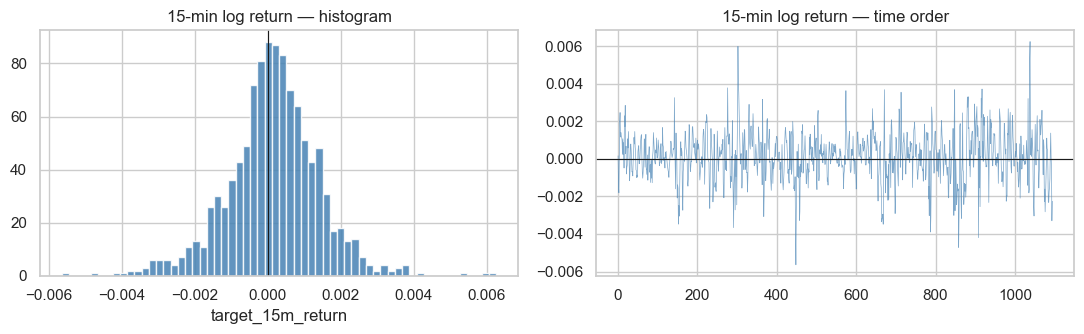

count   1095.0000
mean       0.0001
std        0.0013
min       -0.0056
25%       -0.0005
50%        0.0001
75%        0.0009
max        0.0063
Name: target_15m_return, dtype: float64

skew=-0.059, excess kurt=1.925, P(target>0)=0.557


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df[TARGET], bins=60, alpha=0.85, color="steelblue")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title("15-min log return — histogram")
axes[0].set_xlabel(TARGET)

df[TARGET].plot(ax=axes[1], lw=0.5, alpha=0.7, color="steelblue")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("15-min log return — time order")
plt.tight_layout(); plt.show()

print(df[TARGET].describe())
print(f"\nskew={df[TARGET].skew():.3f}, excess kurt={df[TARGET].kurtosis():.3f}, P(target>0)={(df[TARGET] > 0).mean():.3f}")

## 2. Feature → target correlations

Pearson correlation of each feature with the 15-min return. **Red = GEX features.** If GEX has signal, at least some red bars should rank near the top in absolute value.

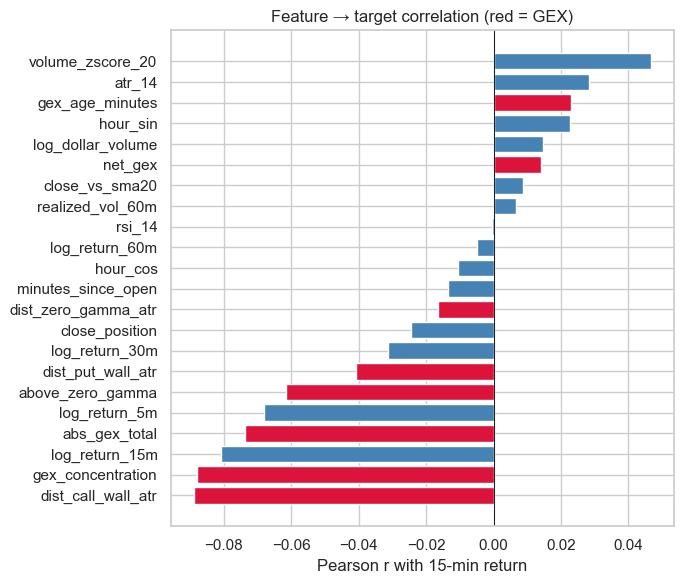

Top features by |r|:
dist_call_wall_atr   0.0890
gex_concentration    0.0879
log_return_15m       0.0809
abs_gex_total        0.0738
log_return_5m        0.0682
above_zero_gamma     0.0616
volume_zscore_20     0.0468
dist_put_wall_atr    0.0407
log_return_30m       0.0314
atr_14               0.0282


In [3]:
corrs = df[ALL_FEATURES].apply(lambda c: c.corr(df[TARGET])).sort_values()
colors = ["crimson" if f in FEATURES_GEX else "steelblue" for f in corrs.index]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("Pearson r with 15-min return")
ax.set_title("Feature → target correlation (red = GEX)")
plt.tight_layout(); plt.show()

print("Top features by |r|:")
print(corrs.abs().sort_values(ascending=False).head(10).to_string())

## 3. Feature multicollinearity

RF and FT-Transformer both tolerate correlated features, but high multicollinearity can muddle SHAP attribution. Flagging pairs with |corr| > 0.8.

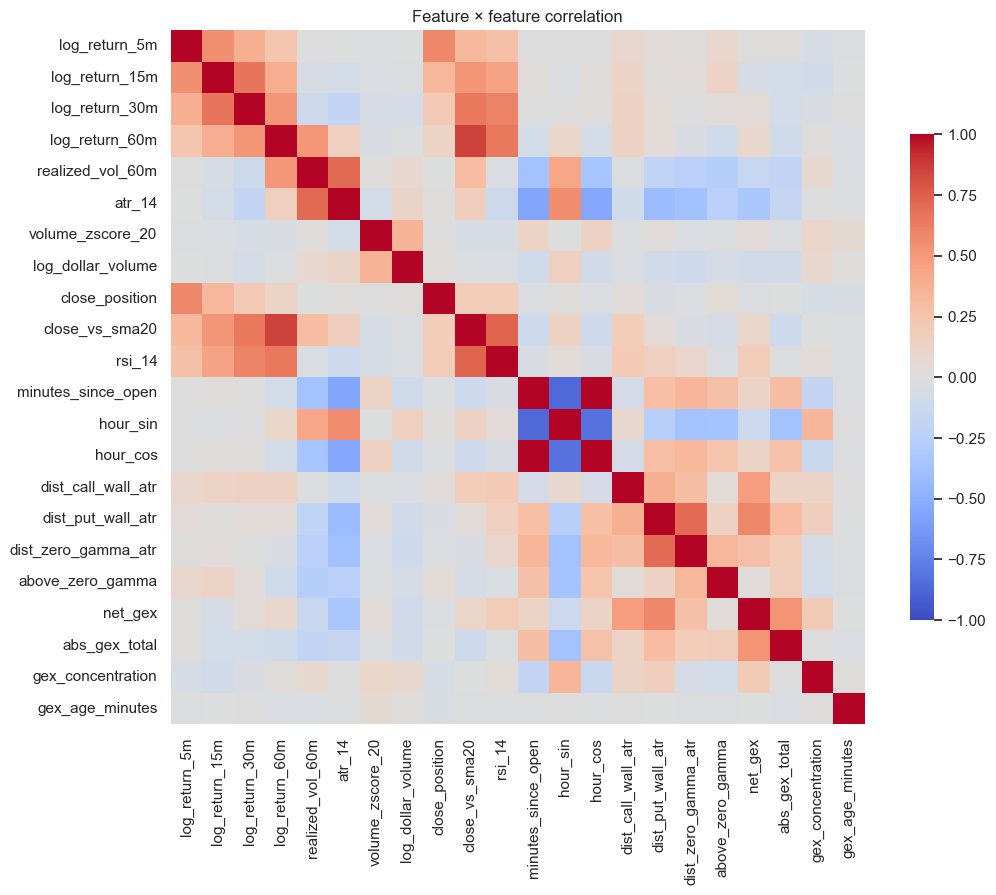

Pairs with |corr| > 0.8 (4 total):
minutes_since_open  hour_cos         0.9965
                    hour_sin         0.8624
log_return_60m      close_vs_sma20   0.8578
hour_sin            hour_cos         0.8204


In [4]:
corr_mat = df[ALL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, annot=False, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature × feature correlation")
plt.tight_layout(); plt.show()

upper = corr_mat.where(np.triu(np.ones_like(corr_mat, dtype=bool), k=1))
high_pairs = upper.stack().abs().sort_values(ascending=False)
high_pairs = high_pairs[high_pairs > 0.8]
print(f"Pairs with |corr| > 0.8 ({len(high_pairs)} total):")
print(high_pairs.to_string() if len(high_pairs) else "(none)")

## 4. Time-series view

Looking for: regime breaks, gaps, GEX features that look suspiciously smooth or have weird jumps.

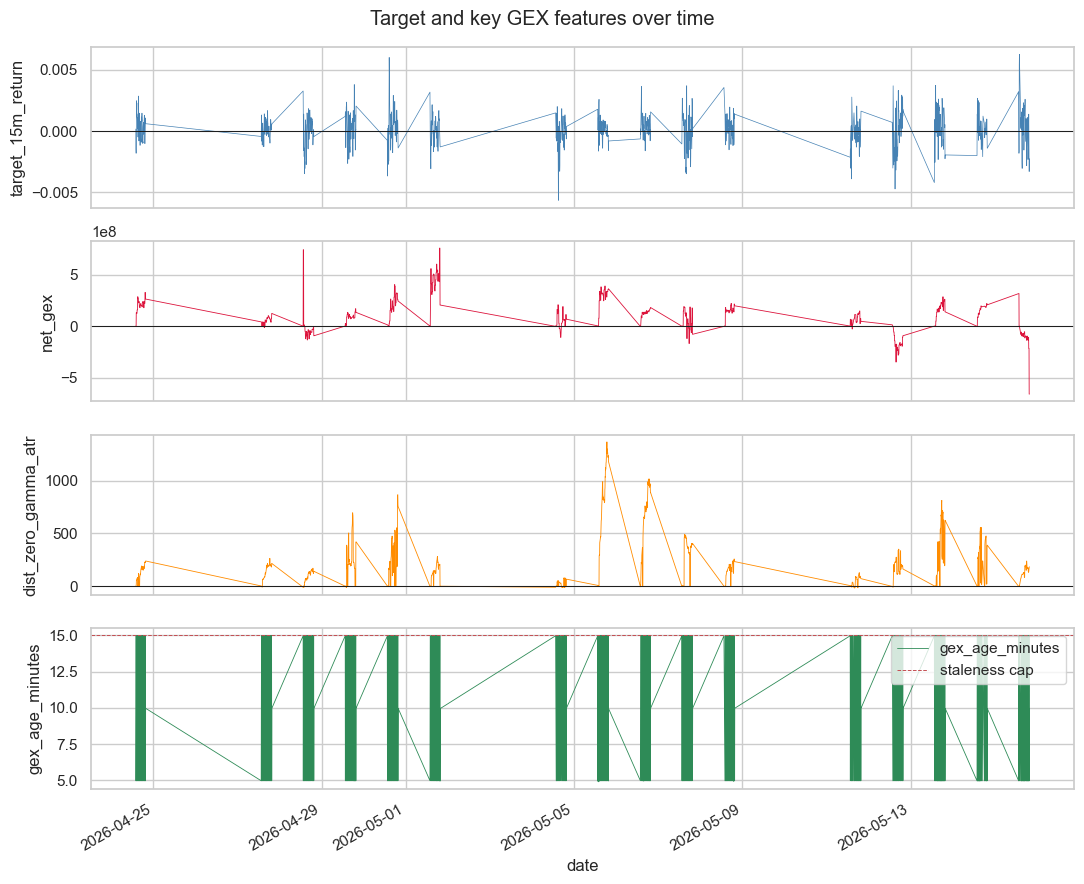

In [5]:
ts = df.set_index("date")
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

ts[TARGET].plot(ax=axes[0], lw=0.5, color="steelblue")
axes[0].axhline(0, color="k", lw=0.7); axes[0].set_ylabel("target_15m_return")

ts["net_gex"].plot(ax=axes[1], color="crimson", lw=0.6)
axes[1].axhline(0, color="k", lw=0.7); axes[1].set_ylabel("net_gex")

ts["dist_zero_gamma_atr"].plot(ax=axes[2], color="darkorange", lw=0.6)
axes[2].axhline(0, color="k", lw=0.7); axes[2].set_ylabel("dist_zero_gamma_atr")

ts["gex_age_minutes"].plot(ax=axes[3], color="seagreen", lw=0.6)
axes[3].axhline(15, color="r", lw=0.7, ls="--", label="staleness cap")
axes[3].set_ylabel("gex_age_minutes"); axes[3].set_xlabel("date"); axes[3].legend()

plt.suptitle("Target and key GEX features over time")
plt.tight_layout(); plt.show()

## 5. Sanity / leakage checks

Explicit asserts. If any of these fire, fix `build_dataset.py` before training.

In [6]:
nans = df[ALL_FEATURES + [TARGET]].isna().sum()
print("NaN counts (should all be 0):")
print(nans[nans > 0] if (nans > 0).any() else "  (none)")

print(f"\nGEX age (min): mean={df.gex_age_minutes.mean():.2f}, max={df.gex_age_minutes.max():.2f} (cap=15)")
assert df.gex_age_minutes.max() <= 15, "GEX staleness cap violated"

gap_min = (df.target_time - df.date).dt.total_seconds() / 60
print(f"Target horizon distinct values (should be only {{15.0}}): {sorted(gap_min.unique())}")
assert (gap_min == 15).all(), "Target horizon not exactly 15 minutes"

assert (df.computed_at <= df.date).all(), "LEAK: GEX computed_at after bar.date"
assert (df.target_time > df.date).all(), "LEAK: target_time at-or-before bar.date"

print("\nAll sanity checks passed.")

NaN counts (should all be 0):
  (none)

GEX age (min): mean=9.95, max=14.98 (cap=15)
Target horizon distinct values (should be only {15.0}): [np.float64(15.0)]

All sanity checks passed.
